# Нейронная сеть Хопфилда для прогнозирования финансовых показателей

**Задание №4:**
- **Вход НС:** Некоторый набор финансовых показателей (курсы акций, валют, цены на сырьё).
- **На выходе НС:** Предсказание на **L** шагов вперёд одного из показателей.
- **Изменяемые параметры:** `M` — ширина окна наблюдения, `D` — глубина задержек, `Ns` — число элементов в скрытом слое.

**Архитектура:** Classical Hopfield Network (непрерывная версия) реализована через TensorFlow/Keras.  
Сеть Хопфилда используется как ассоциативная память: окно исторических цен кодируется в «паттерн», а слой Хопфилда извлекает из обученной памяти наиболее близкое состояние, которое затем декодируется в прогноз.

---
**Параметры сети:**
| Параметр | Описание |
|----------|----------|
| `M` | Ширина окна наблюдения (кол-во дней в истории) |
| `D` | Глубина задержек (шаг дискретизации внутри окна) |
| `L` | Горизонт прогнозирования (кол-во дней вперёд) |
| `Ns` | Число нейронов в скрытом/ассоциативном слое |

## 1. Импорт библиотек и настройка GPU

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# ── Настройка GPU (NVIDIA) ──────────────────────────────────────────────────
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"✓ Найдено GPU: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Память GPU будет выделяться по мере необходимости (memory growth)")
    except RuntimeError as e:
        print(f"⚠ Ошибка настройки памяти: {e}")
    tf.config.set_visible_devices(gpus[0], "GPU")
    print(f"✓ Активный GPU: {gpus[0].name}")
else:
    print("⚠ GPU не найдено, используется CPU")

print(f"\nTensorFlow версия: {tf.__version__}")
print(f'Используемое устройство: {"GPU" if gpus else "CPU"}')

2026-04-01 19:25:34.517582: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Найдено GPU: 1
  GPU 0: /physical_device:GPU:0
✓ Память GPU будет выделяться по мере необходимости (memory growth)
✓ Активный GPU: /physical_device:GPU:0

TensorFlow версия: 2.20.0
Используемое устройство: GPU


## 2. Гиперпараметры эксперимента

In [ ]:
# ── Базовые параметры (фиксируются при варьировании одного из параметров) ──
M = 30  # Ширина окна наблюдения (дней)
D = 1  # Глубина задержек (шаг выборки внутри окна)
L = 5  # Горизонт прогнозирования (дней вперёд)
Ns = 128  # Число нейронов в скрытом (ассоциативном) слое Хопфилда
BETA = 1.0  # Температурный параметр softmax в сети Хопфилда
EPOCHS = 60  # Эпохи обучения
BATCH = 32  # Размер мини-батча

print("Параметры эксперимента:")
print(f"  M  = {M}  (ширина окна)")
print(f"  D  = {D}  (глубина задержек)")
print(f"  L  = {L}  (горизонт прогноза)")
print(f"  Ns = {Ns} (нейронов в слое Хопфилда)")
print(f"  β  = {BETA} (температура)")

Параметры эксперимента:
  M  = 30  (ширина окна)
  D  = 1  (глубина задержек)
  L  = 5  (горизонт прогноза)
  Ns = 128 (нейронов в слое Хопфилда)
  β  = 1.0 (температура)


## 3. Загрузка финансовых данных

Используем котировки золота (GC=F) как основной прогнозируемый показатель.

Загружено строк: 1572


,gold,silver
Date,,
2020-01-02,1524.500000,17.966000
2020-01-03,1549.199951,18.068001
2020-01-06,1566.199951,18.097000
2020-01-07,1571.800049,18.316000
2020-01-08,1557.400024,18.087999


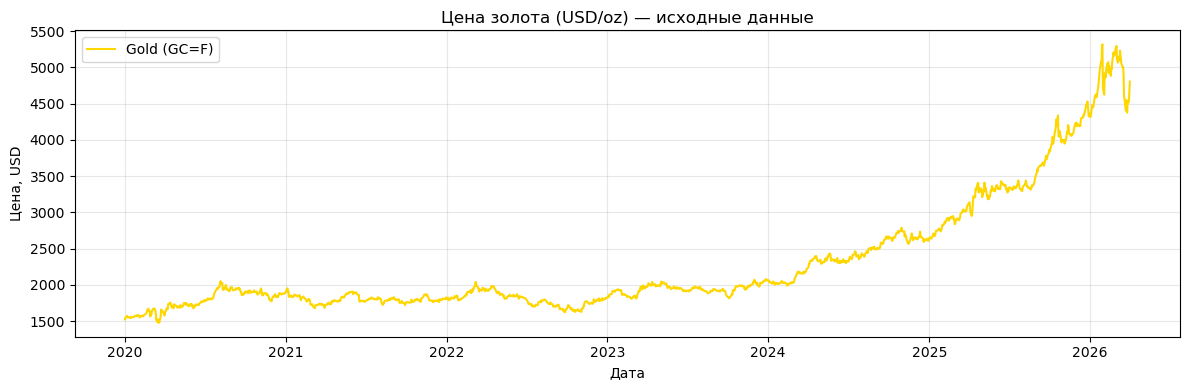

In [ ]:
tickers = ["GC=F", "SI=F"]
raw = yf.download(tickers, start="2020-01-01", progress=False)

gold = raw["Close"]["GC=F"]
silver = raw["Close"]["SI=F"]

data = pd.DataFrame({"gold": gold, "silver": silver}).dropna()
print(f"Загружено строк: {len(data)}")
display(data.head())

plt.figure(figsize=(12, 4))
plt.plot(data.index, data["gold"], label="Gold (GC=F)", color="gold")
plt.title("Цена золота (USD/oz) — исходные данные")
plt.xlabel("Дата")
plt.ylabel("Цена, USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Предобработка данных

Нормализация + формирование скользящих окон с параметрами M, D, L.

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[["gold"]])


def build_dataset(series, M, D, L):
    """Формирует пары (X, y): X — скользящее окно, y — значение через L шагов.

    Args:
        series: нормализованный массив цен (ожидается 2D или 1D)
        M: ширина окна наблюдения (временной интервал)
        D: шаг задержки (стрейд)
        L: горизонт прогнозирования
    """
    X, y = [], []
    n = len(series)

    # Убедимся, что series — numpy массив для корректной индексации
    if not isinstance(series, np.ndarray):
        series = np.array(series)

    for i in range(M, n - L):

        start_idx = i - M
        indices = list(range(start_idx, i, D))

        # Проверка на случай, если indices пуст (защита от ошибок при больших D)
        if not indices:
            continue

        window = series[indices].flatten()

        # Обработка target в зависимости от размерности series
        if series.ndim == 1:
            target = series[i + L]
        else:
            target = series[i + L, 0]

        X.append(window)
        y.append(target)

    # Теперь все элементы в X имеют одинаковую длину, ошибка исчезнет
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X, y = build_dataset(data_scaled, M, D, L)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Обучающая выборка:  {X_train.shape[0]} образцов, признаков: {X_train.shape[1]}")
print(f"Тестовая выборка:   {X_test.shape[0]} образцов")

Обучающая выборка:  1229 образцов, признаков: 30
Тестовая выборка:   308 образцов


## 5. Архитектура: Classic Hopfield Network

### Теоретическая база

**Классическая сеть Хопфилда** (Hopfield, 1982) — это рекуррентная сеть с симметричными весами, используемая как ассоциативная память. Энергетическая функция:

$$E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j$$

**Classical Hopfield Networks** (Ramsauer et al., 2020) — непрерывная версия с экспоненциальной ёмкостью памяти. Правило обновления состояния:

$$\mathbf{x}^{\text{new}} = X^T \cdot \text{softmax}(\beta \cdot X \cdot \mathbf{x})$$

где $X$ — матрица хранимых паттернов, $\beta$ — обратная температура.

**Ключевое свойство:** один шаг Classical Hopfield = механизм **cross-attention** (как в трансформерах), что позволяет нативно интегрировать его в Keras как Custom Layer.

**Схема модели для прогнозирования:**
```
Вход [batch, n_features]
  → Dense (Encoder) [batch, Ns]          # Кодирование запроса
  → HopfieldLayer (Ассоциативная память) # Извлечение из памяти
  → Dense (Decoder) [batch, 1]           # Декодирование прогноза
```

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model


# --- Вспомогательная функция для градиента (STE) ---
@tf.custom_gradient
def sign_with_ste(x):
    """
    Функция sign с Straight-Through Estimator для обучения.
    Forward: возвращает -1 или 1
    Backward: пропускает градиент как есть (как identity)
    """

    def grad(dy):
        return dy  # Пропускаем градиент без изменений

    return tf.sign(x), grad


class ClassicalHopfieldLayer(layers.Layer):
    """Classical Hopfield Layer (1982) — дискретная ассоциативная память.

    Реализует рекуррентное обновление состояния классической сети Хопфилда:
        s_new = sign(W · s_old)

    Особенности реализации:
    - Использует симметричную матрицу весов W [dim, dim]
    - Требует нескольких итераций для сходимости
    - Нейроны имеют бинарные состояния (-1, +1) через функцию sign
    - Использует STE (Straight-Through Estimator) для возможности backprop

    Параметры:
        num_neurons:    число нейронов в сети (размерность состояния)
        num_iterations: число шагов обновления для сходимости
    """

    def __init__(self, num_neurons: int, num_iterations: int = 5, **kwargs):
        super().__init__(**kwargs)
        self.num_neurons = num_neurons
        self.num_iterations = num_iterations

    def build(self, input_shape):
        # Симметричная матрица весов W [num_neurons, num_neurons]
        # w_ij = w_ji, диагональ = 0 (нейрон не связан сам с собой)
        self.W = self.add_weight(
            name="weight_matrix",
            shape=(self.num_neurons, self.num_neurons),
            initializer="glorot_uniform",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        """
        inputs: [batch, num_neurons] — начальное состояние сети
        Returns: [batch, num_neurons] — состояние после итераций (бинарное)
        """
        state = inputs

        # Рекуррентное обновление состояния
        for _ in range(self.num_iterations):
            # h = W · s
            h = tf.matmul(state, self.W)
            # s_new = sign(h) с STE для обучения
            state = sign_with_ste(h)

        return state

    def store_patterns(self, patterns):
        """
        Записывает паттерны в память по правилу Хебба.
        W = Σ (ξ · ξ^T) / N

        Args:
            patterns: [num_patterns, num_neurons] — эталонные векторы (-1, +1)
        """
        patterns = tf.cast(patterns, tf.float32)
        num_patterns = tf.shape(patterns)[0]

        # Правило Хебба: W = (1/N) * Σ ξ ξ^T
        W_hebb = tf.matmul(patterns, patterns, transpose_a=True) / tf.cast(
            num_patterns, tf.float32
        )

        # Обнуляем диагональ (нейроны не связаны сами с собой)
        mask = 1.0 - tf.eye(self.num_neurons)
        W_hebb = W_hebb * mask

        # Присваиваем веса
        self.W.assign(W_hebb)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(
            {"num_neurons": self.num_neurons, "num_iterations": self.num_iterations}
        )
        return cfg


def build_hopfield_model(
    n_features: int, Ns: int = 128, num_iterations: int = 5
) -> Model:
    """Строит модель на основе Classical Hopfield Network.

    Args:
        n_features:      размерность входного вектора
        Ns:              число нейронов в слое Хопфилда
        num_iterations:  число шагов обновления
    Returns:
        Скомпилированная Keras-модель
    """
    inp = layers.Input(shape=(n_features,), name="input")

    # Encoder: проецируем вход в пространство состояний Хопфилда
    # Выход encoder должен быть в диапазоне [-1, 1] для корректной работы sign
    encoded = layers.Dense(Ns, activation="tanh", name="encoder")(inp)

    # Classical Hopfield Layer: рекуррентное обновление до сходимости
    hopf = ClassicalHopfieldLayer(
        num_neurons=Ns, num_iterations=num_iterations, name="hopfield_classical"
    )(encoded)

    # Residual connection + нормализация
    merged = layers.Add(name="residual")([encoded, hopf])
    normed = layers.LayerNormalization(name="layer_norm")(merged)

    # Decoder: прогноз
    out = layers.Dense(1, activation="linear", name="output")(normed)

    model = Model(inputs=inp, outputs=out, name="ClassicalHopfieldNet")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


# Демонстрация архитектуры с базовыми параметрами
demo_model = build_hopfield_model(n_features=X_train.shape[1], Ns=Ns)
demo_model.summary()

I0000 00:00:1775060739.741471  106968 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:2b:00.0, compute capability: 8.9


Model: "ClassicalHopfieldNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (Dense)     │ (None, 128)       │      3,968 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hopfield_classical  │ (None, 128)       │     16,384 │ encoder[0][0]     │
│ (ClassicalHopfield… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 128)       │          0 │ encoder[0][0],    │
│                     │                   │            │ hopfield_classic… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm          │ (None, 128)       │        256 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ layer_norm[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,737 (81.00 KB)

 Trainable params: 20,737 (81.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Базовое обучение модели

Epoch 1/60


2026-04-01 19:25:41.533649: I external/local_xla/xla/service/service.cc:163] XLA service 0x714b7c006800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-01 19:25:41.533685: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-04-01 19:25:41.557446: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-01 19:25:41.663727: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-04-01 19:25:41.692415: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:25:41.692474: 

23/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6263 - mae: 1.0032 

I0000 00:00:1775060746.607622  107050 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.4210 - mae: 0.9356

2026-04-01 19:25:48.960368: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:25:48.960436: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:25:50.105297: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 19:25:50.125274: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - loss: 1.0176 - mae: 0.7903 - val_loss: 1.9013 - val_mae: 1.1480
Epoch 2/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3275 - mae: 0.4476 - val_loss: 0.2088 - val_mae: 0.3993
Epoch 3/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1118 - mae: 0.2873 - val_loss: 0.2007 - val_mae: 0.3907
Epoch 4/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1371 - mae: 0.2952 - val_loss: 0.1248 - val_mae: 0.2746
Epoch 5/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0888 - mae: 0.2364 - val_loss: 0.0498 - val_mae: 0.2141
Epoch 6/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1856 - mae: 0.3009 - val_loss: 0.1640 - val_mae: 0.3613
Epoch 7/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1072 - mae: 0.2278 - val_loss: 0.1270 - val_mae: 0.2993
Epoch 8/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0389 - mae: 0.1600 - val_loss: 0.1647 - val_mae: 0.3736
Epoch 9/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0342 - mae: 0.1441 -

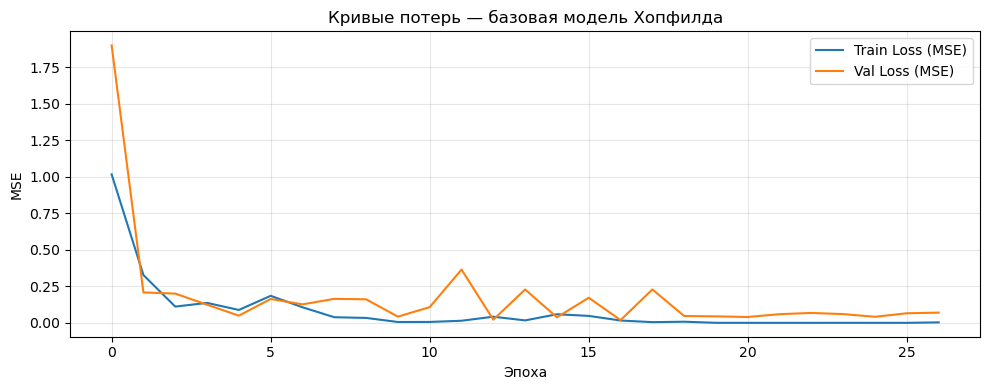

In [ ]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=60,
    batch_size=32,
    early_stop=True,
    patience=10,
    verbose=0,
):
    """Обучение модели с опциональным EarlyStopping."""
    callbacks = []
    if early_stop:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True,
                verbose=0,
            )
        )
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )
    return history


with tf.device("/GPU:0" if gpus else "/CPU:0"):
    base_model = build_hopfield_model(X_train.shape[1], Ns=Ns)
    base_history = train_model(
        base_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=EPOCHS,
        batch_size=BATCH,
        early_stop=True,
        verbose=1,
    )

train_loss = base_history.history["loss"]
val_loss = base_history.history["val_loss"]
print(f"\nЛучший val_loss: {min(val_loss):.6f}")

# ── График кривых обучения ──────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_loss, label="Train Loss (MSE)")
plt.plot(val_loss, label="Val Loss (MSE)")
plt.title("Кривые потерь — базовая модель Хопфилда")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Прогнозирование и визуализация результатов

RMSE (train): 126.74 USD
RMSE (test):  532.56 USD


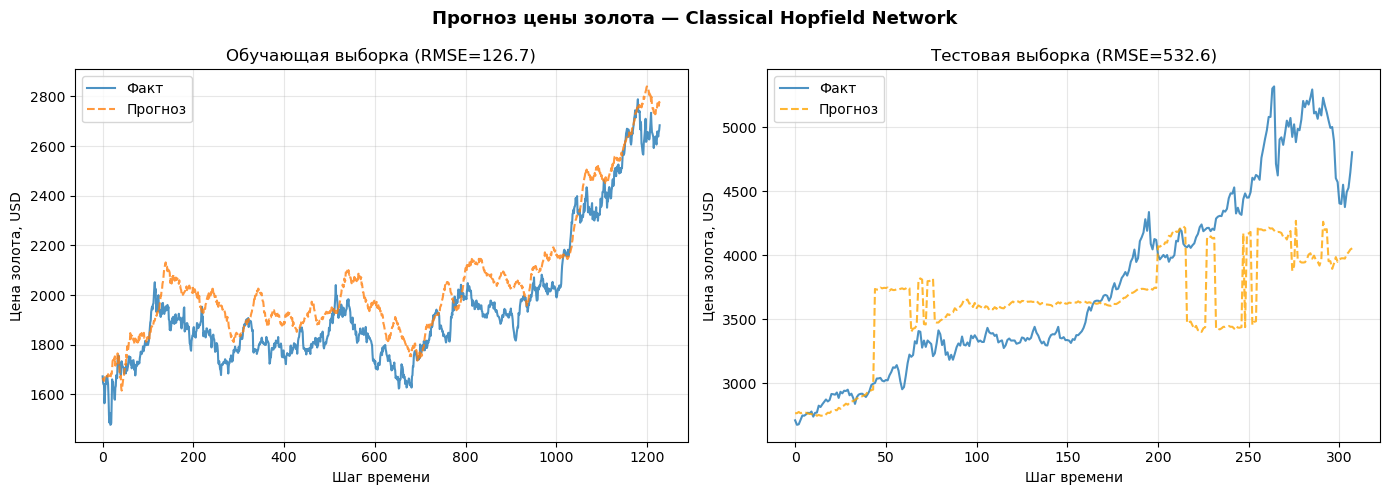

In [ ]:
y_pred_train = base_model.predict(X_train, verbose=0).flatten()
y_pred_test = base_model.predict(X_test, verbose=0).flatten()


# Обратное масштабирование
def inverse(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


y_train_real = inverse(y_train)
y_test_real = inverse(y_test)
y_pred_train_real = inverse(y_pred_train)
y_pred_test_real = inverse(y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train_real, y_pred_train_real))
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
print(f"RMSE (train): {rmse_train:.2f} USD")
print(f"RMSE (test):  {rmse_test:.2f} USD")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_train_real, label="Факт", alpha=0.8)
axes[0].plot(y_pred_train_real, label="Прогноз", alpha=0.8, linestyle="--")
axes[0].set_title(f"Обучающая выборка (RMSE={rmse_train:.1f})")
axes[0].set_xlabel("Шаг времени")
axes[0].set_ylabel("Цена золота, USD")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(y_test_real, label="Факт", alpha=0.8)
axes[1].plot(
    y_pred_test_real, label="Прогноз", alpha=0.8, linestyle="--", color="orange"
)
axes[1].set_title(f"Тестовая выборка (RMSE={rmse_test:.1f})")
axes[1].set_xlabel("Шаг времени")
axes[1].set_ylabel("Цена золота, USD")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Прогноз цены золота — Classical Hopfield Network", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 8. Зависимость функции потерь от параметров M, D, L, Ns

По очереди варьируем **один параметр**, остальные фиксируются на базовых значениях.

In [ ]:
def run_sweep(
    param_name,
    param_values,
    base_M=30,
    base_D=1,
    base_L=5,
    base_Ns=128,
    epochs=40,
    batch_size=32,
):
    """Запускает серию экспериментов, варьируя один параметр.

    Returns:
        dict: param_value → {'train_loss': [...], 'val_loss': [...],
                              'final_train': float, 'final_val': float}
    """
    results = {}
    for val in param_values:
        cur_M = val if param_name == "M" else base_M
        cur_D = val if param_name == "D" else base_D
        cur_L = val if param_name == "L" else base_L
        cur_Ns = val if param_name == "Ns" else base_Ns

        Xi, yi = build_dataset(data_scaled, cur_M, cur_D, cur_L)
        if len(Xi) < 50:
            print(f"  [{param_name}={val}] Недостаточно данных, пропуск")
            continue
        sp = int(len(Xi) * 0.8)
        Xtr, Xte = Xi[:sp], Xi[sp:]
        ytr, yte = yi[:sp], yi[sp:]

        with tf.device("/GPU:0" if gpus else "/CPU:0"):
            model = build_hopfield_model(Xtr.shape[1], Ns=cur_Ns)
            hist = train_model(
                model,
                Xtr,
                ytr,
                Xte,
                yte,
                epochs=epochs,
                batch_size=batch_size,
                early_stop=False,
                verbose=0,
            )

        tl = hist.history["loss"]
        vl = hist.history["val_loss"]
        results[val] = {
            "train_loss": tl,
            "val_loss": vl,
            "final_train": tl[-1],
            "final_val": vl[-1],
        }
        print(
            f"  [{param_name}={val:>4}] train_loss={tl[-1]:.5f}  val_loss={vl[-1]:.5f}"
        )
    return results


def plot_sweep_curves(results, param_name, title_suffix=""):
    """Строит кривые обучения и итоговый bar-chart для одного sweep."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cmap = plt.get_cmap("viridis", len(results))
    values = sorted(results.keys())

    for idx, v in enumerate(values):
        color = cmap(idx)
        axes[0].plot(
            results[v]["train_loss"],
            color=color,
            linestyle="--",
            alpha=0.7,
            linewidth=1,
        )
        axes[0].plot(
            results[v]["val_loss"],
            color=color,
            label=f"{param_name}={v}",
            linewidth=1.5,
        )

    axes[0].set_title(f"Кривые потерь при варьировании {param_name}{title_suffix}")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("MSE")
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(alpha=0.3)

    final_train = [results[v]["final_train"] for v in values]
    final_val = [results[v]["final_val"] for v in values]
    x_pos = np.arange(len(values))
    w = 0.35
    axes[1].bar(x_pos - w / 2, final_train, w, label="Train Loss", alpha=0.8)
    axes[1].bar(x_pos + w / 2, final_val, w, label="Val Loss", alpha=0.8)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(v) for v in values])
    axes[1].set_title(f"Итоговые потери vs {param_name}")
    axes[1].set_xlabel(param_name)
    axes[1].set_ylabel("MSE (финальная эпоха)")
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle(
        f"Влияние параметра {param_name} на функцию потерь",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

### 8.1 Варьирование M — ширины окна наблюдения

Sweep по M (D=1, L=5, Ns=128)


2026-04-01 19:26:01.651621: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:26:01.651675: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:26:02.902294: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 36 bytes spill stores, 36 bytes spill loads

2026-04-01 19:26:02.972480: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [M=   5] train_loss=0.00147  val_loss=0.06705


2026-04-01 19:26:13.465390: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:26:13.465452: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:26:13.465466: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:26:14.120031: I external/l

  [M=  10] train_loss=0.00056  val_loss=0.00498


...

  [M=  20] train_loss=0.00201  val_loss=0.01171
  [M=  30] train_loss=0.00028  val_loss=0.05424


2026-04-01 19:26:54.674888: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:26:55.335865: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 16 bytes spill stores, 16 bytes spill loads

2026-04-01 19:26:55.462323: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 16 bytes spill stores, 16 bytes spill loads

2026-04-01 19:26:55.731591: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 416 byte

  [M=  50] train_loss=0.00180  val_loss=0.06142


2026-04-01 19:27:07.381964: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:27:08.011805: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 16 bytes spill stores, 16 bytes spill loads

2026-04-01 19:27:08.431868: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_575', 240 bytes spill stores, 240 bytes spill loads



  [M=  70] train_loss=0.00029  val_loss=0.02300


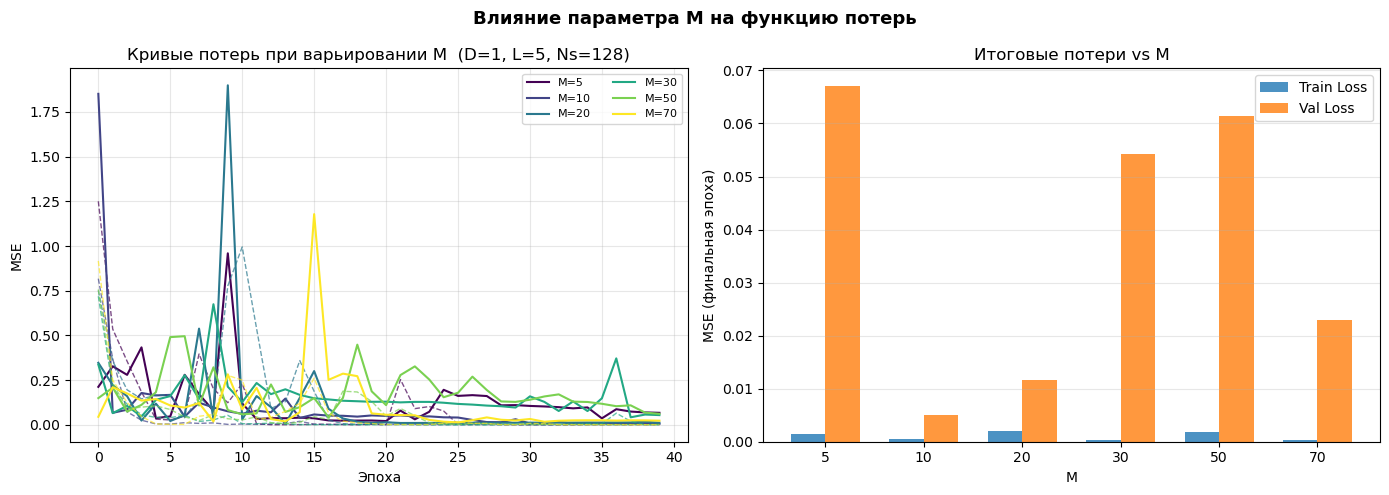

In [ ]:
M_values = [5, 10, 20, 30, 50, 70]
print(f"Sweep по M (D={D}, L={L}, Ns={Ns})")
results_M = run_sweep("M", M_values, base_D=D, base_L=L, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_M, "M", f"  (D={D}, L={L}, Ns={Ns})")

### 8.2 Варьирование D — глубины задержек

Sweep по D (M=30, L=5, Ns=128)
  [D=   1] train_loss=0.00051  val_loss=0.13791
  [D=   2] train_loss=0.00042  val_loss=0.13087
  [D=   3] train_loss=0.00065  val_loss=0.02664
  [D=   5] train_loss=0.00050  val_loss=0.07454
  [D=   7] train_loss=0.00039  val_loss=0.02812
  [D=  10] train_loss=0.00127  val_loss=0.08084


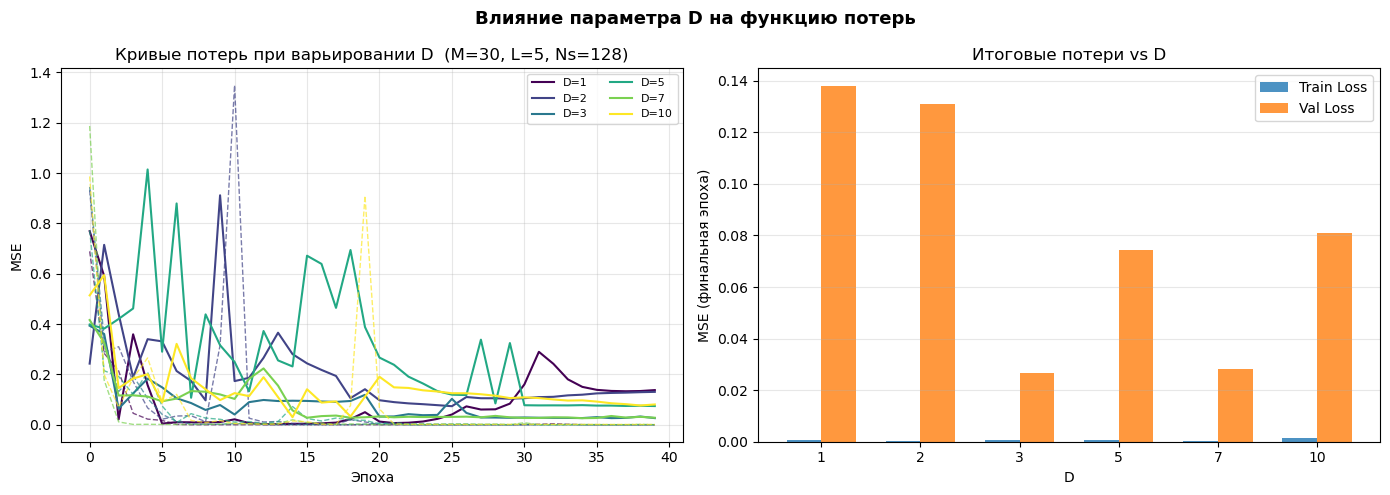

In [ ]:
D_values = [1, 2, 3, 5, 7, 10]
print(f"Sweep по D (M={M}, L={L}, Ns={Ns})")
results_D = run_sweep("D", D_values, base_M=M, base_L=L, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_D, "D", f"  (M={M}, L={L}, Ns={Ns})")

### 8.3 Варьирование L — горизонта прогнозирования

Sweep по L (M=30, D=1, Ns=128)
  [L=   1] train_loss=0.00227  val_loss=0.16230
  [L=   3] train_loss=0.00027  val_loss=0.03739
  [L=   5] train_loss=0.02776  val_loss=0.33075


2026-04-01 19:29:11.127230: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:29:11.127288: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:29:12.045066: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 36 bytes spill stores, 36 bytes spill loads

2026-04-01 19:29:12.265298: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [L=  10] train_loss=0.00049  val_loss=0.01260


2026-04-01 19:29:24.700073: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:29:24.700132: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:29:25.593389: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 19:29:25.612628: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [L=  15] train_loss=0.00061  val_loss=0.10267


2026-04-01 19:29:37.359408: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:29:37.359469: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:29:38.032324: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 19:29:38.599345: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

  [L=  20] train_loss=0.00102  val_loss=0.05617


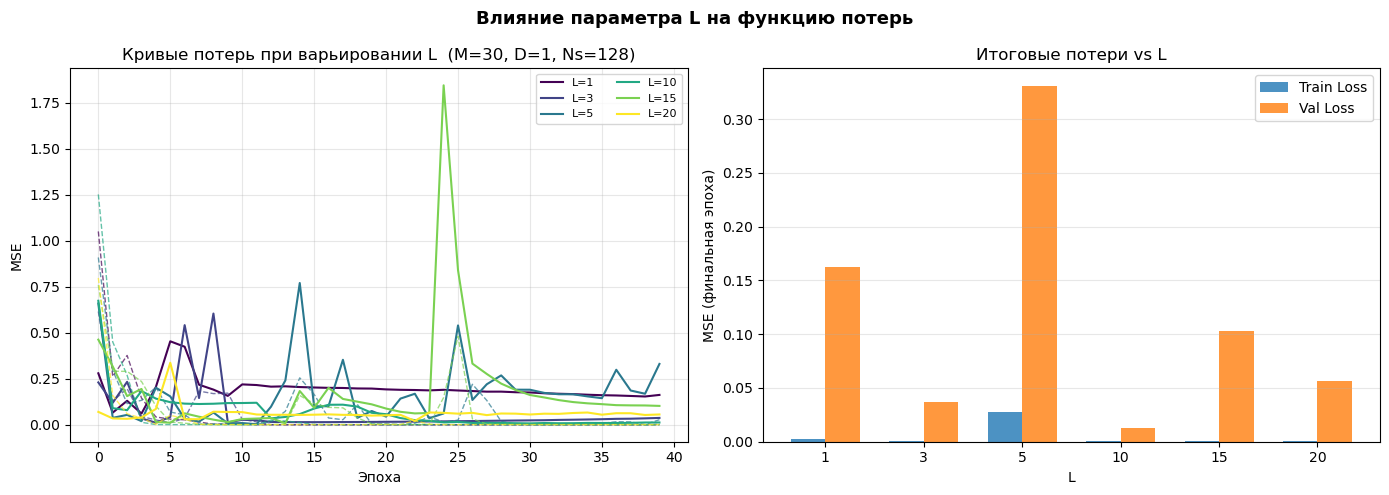

In [ ]:
L_values = [1, 3, 5, 10, 15, 20]
print(f"Sweep по L (M={M}, D={D}, Ns={Ns})")
results_L = run_sweep("L", L_values, base_M=M, base_D=D, base_Ns=Ns, epochs=40)
plot_sweep_curves(results_L, "L", f"  (M={M}, D={D}, Ns={Ns})")

### 8.4 Варьирование Ns — числа нейронов в слое Хопфилда

Sweep по Ns (M=30, D=1, L=5)
  [Ns=  16] train_loss=0.00025  val_loss=0.03753
  [Ns=  32] train_loss=0.00047  val_loss=0.24972


2026-04-01 19:30:11.459431: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 16 bytes spill stores, 16 bytes spill loads



  [Ns=  64] train_loss=0.00452  val_loss=0.24870
  [Ns= 128] train_loss=0.00782  val_loss=0.09675


2026-04-01 19:30:30.321359: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:30:30.321420: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:30:30.321437: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:30:30.321460: I external/l

  [Ns= 256] train_loss=0.00025  val_loss=0.01383


...

  [Ns=1024] train_loss=0.02615  val_loss=0.10643


2026-04-01 19:31:14.776868: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:31:15.430687: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 4 bytes spill stores, 4 bytes spill loads

2026-04-01 19:31:15.820077: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 56 bytes spill stores, 56 bytes spill loads

2026-04-01 19:31:16.041939: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_139', 332 bytes 

  [Ns=2048] train_loss=0.00044  val_loss=0.09271


2026-04-01 19:31:31.853556: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 19:31:32.503881: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 4 bytes spill stores, 4 bytes spill loads

2026-04-01 19:31:32.837731: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_553', 136 bytes spill stores, 136 bytes spill loads

2026-04-01 19:31:32.945806: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 4 bytes 

  [Ns=4096] train_loss=0.00177  val_loss=0.03561


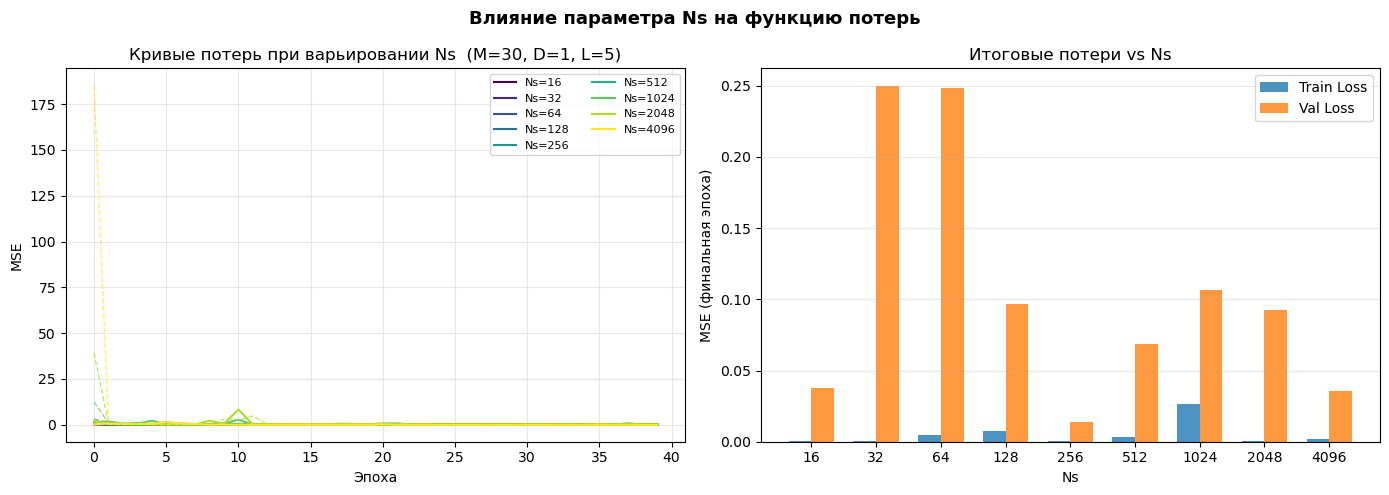

In [ ]:
Ns_values = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
print(f"Sweep по Ns (M={M}, D={D}, L={L})")
results_Ns = run_sweep("Ns", Ns_values, base_M=M, base_D=D, base_L=L, epochs=40)
plot_sweep_curves(results_Ns, "Ns", f"  (M={M}, D={D}, L={L})")

## 9. Демонстрация переобучения

Чтобы вызвать переобучение, используем:
- **Очень большой Ns** (много параметров, много «паттернов памяти»)
- **Маленький объём обучающих данных** (M=5, малое окно → мало признаков и образцов)
- **Отсутствие ранней остановки** и большое число эпох

Параметры для демонстрации переобучения: M=10, Ns=1024, epochs=200
Обучающая выборка: 1245 образцов


2026-04-01 19:35:41.157300: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_553', 4 bytes spill stores, 4 bytes spill loads



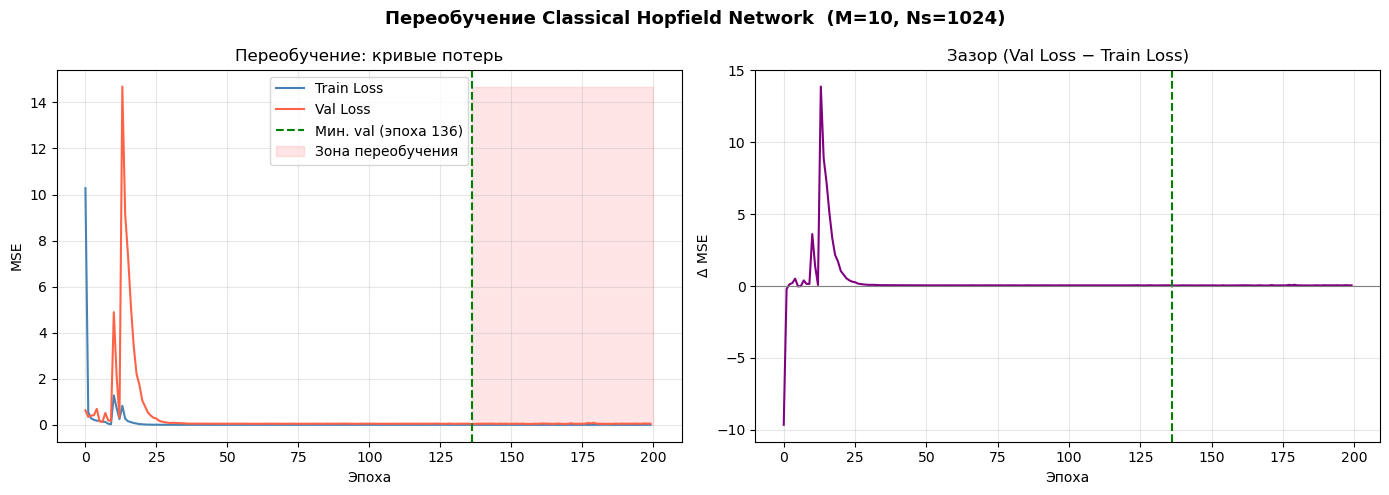


Минимальный val_loss на эпохе 136: 0.03351
Финальный train_loss: 0.00053  |  Финальный val_loss: 0.04893
Зазор переобучения: 0.04840


In [ ]:
# Настройки, провоцирующие переобучение
M_of = 10  # Маленькое окно
Ns_of = 1024  # Гигантский скрытый слой
EPC_OF = 200  # Много эпох, без ранней остановки

X_of, y_of = build_dataset(data_scaled, M_of, D=1, L=L)
sp_of = int(len(X_of) * 0.8)
X_tr_of, X_te_of = X_of[:sp_of], X_of[sp_of:]
y_tr_of, y_te_of = y_of[:sp_of], y_of[sp_of:]

print(f"Параметры для демонстрации переобучения: M={M_of}, Ns={Ns_of}, epochs={EPC_OF}")
print(f"Обучающая выборка: {len(X_tr_of)} образцов")

with tf.device("/GPU:0" if gpus else "/CPU:0"):
    overfit_model = build_hopfield_model(X_tr_of.shape[1], Ns=Ns_of)
    overfit_history = train_model(
        overfit_model,
        X_tr_of,
        y_tr_of,
        X_te_of,
        y_te_of,
        epochs=EPC_OF,
        batch_size=BATCH,
        early_stop=False,
        verbose=0,
    )

tl_of = overfit_history.history["loss"]
vl_of = overfit_history.history["val_loss"]

# ── Поиск точки начала переобучения ────────────────────────────────────────
best_val_epoch = int(np.argmin(vl_of))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Кривые потерь
axes[0].plot(tl_of, label="Train Loss", color="steelblue")
axes[0].plot(vl_of, label="Val Loss", color="tomato")
axes[0].axvline(
    best_val_epoch,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"Мин. val (эпоха {best_val_epoch})",
)
axes[0].fill_betweenx(
    [0, max(vl_of)],
    best_val_epoch,
    EPC_OF,
    alpha=0.1,
    color="red",
    label="Зона переобучения",
)
axes[0].set_title("Переобучение: кривые потерь")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Зазор train/val по эпохам
gap = np.array(vl_of) - np.array(tl_of)
axes[1].plot(gap, color="purple")
axes[1].axvline(best_val_epoch, color="green", linestyle="--", linewidth=1.5)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Зазор (Val Loss − Train Loss)")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Δ MSE")
axes[1].grid(alpha=0.3)

plt.suptitle(
    f"Переобучение Classical Hopfield Network  (M={M_of}, Ns={Ns_of})",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"\nМинимальный val_loss на эпохе {best_val_epoch}: {min(vl_of):.5f}")
print(f"Финальный train_loss: {tl_of[-1]:.5f}  |  Финальный val_loss: {vl_of[-1]:.5f}")
print(f"Зазор переобучения: {vl_of[-1] - tl_of[-1]:.5f}")

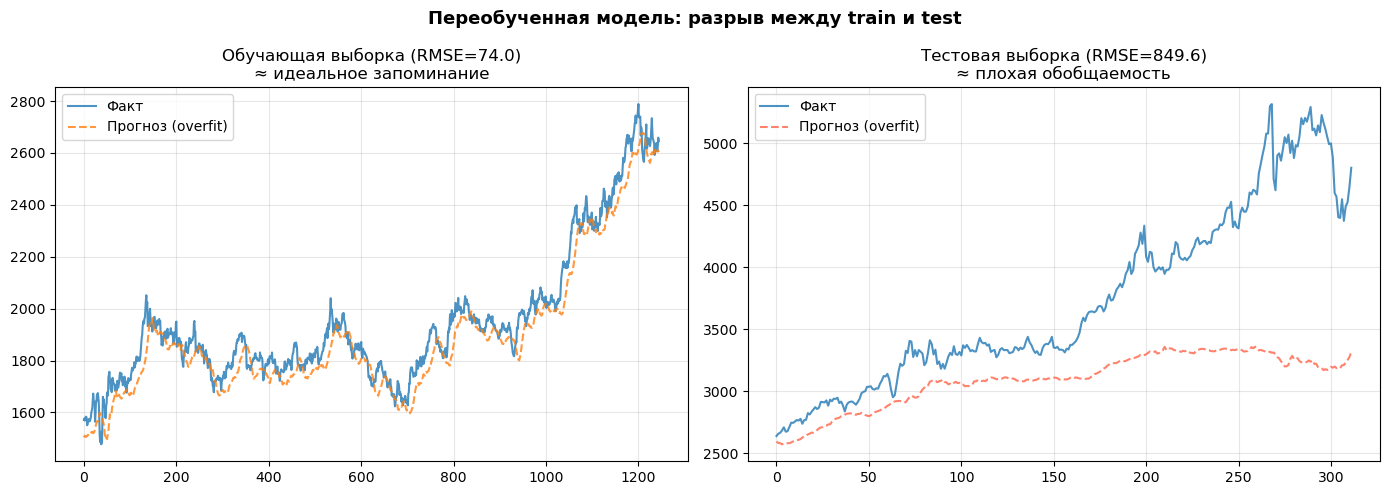

In [ ]:
# Сравнение прогнозов: переобученная vs нормальная модель
y_pred_of_train = overfit_model.predict(X_tr_of, verbose=0).flatten()
y_pred_of_test = overfit_model.predict(X_te_of, verbose=0).flatten()


def inv(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# На train — отличное совпадение (запомнила данные)
axes[0].plot(inv(y_tr_of), label="Факт", alpha=0.8)
axes[0].plot(inv(y_pred_of_train), label="Прогноз (overfit)", linestyle="--", alpha=0.8)
rmse_tr = np.sqrt(mean_squared_error(inv(y_tr_of), inv(y_pred_of_train)))
axes[0].set_title(f"Обучающая выборка (RMSE={rmse_tr:.1f})\n≈ идеальное запоминание")
axes[0].legend()
axes[0].grid(alpha=0.3)

# На test — плохое качество
axes[1].plot(inv(y_te_of), label="Факт", alpha=0.8)
axes[1].plot(
    inv(y_pred_of_test),
    label="Прогноз (overfit)",
    linestyle="--",
    alpha=0.8,
    color="tomato",
)
rmse_te = np.sqrt(mean_squared_error(inv(y_te_of), inv(y_pred_of_test)))
axes[1].set_title(f"Тестовая выборка (RMSE={rmse_te:.1f})\n≈ плохая обобщаемость")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Переобученная модель: разрыв между train и test", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()